Import Library

# Deep RNN Model
## DeteksiSarkasme.json

In [26]:
!pip install -q keras-tuner

Import Library

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import keras_tuner as kt

Load Dataset

In [29]:
!wget -O DeteksiSarkasme.json https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/DeteksiSarkasme.json

--2025-05-01 09:01:30--  https://raw.githubusercontent.com/farrelrassya/teachingMLDL/main/02.%20Deep%20Learning/07.%20Week%207/Datasets/DeteksiSarkasme.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5616830 (5.4M) [text/plain]
Saving to: ‘DeteksiSarkasme.json’

DeteksiSarkasme.jso 100%[===================>]   5.36M  --.-KB/s    in 0.02s   

2025-05-01 09:01:30 (289 MB/s) - ‘DeteksiSarkasme.json’ saved [5616830/5616830]



In [30]:
with open('DeteksiSarkasme.json', 'r') as f:
    data = [json.loads(line) for line in f]

# Konversi ke DataFrame
df = pd.DataFrame(data)

# Tampilkan beberapa baris pertama
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


Preprocessing

In [31]:
texts = df['headline']
labels = df['is_sarcastic']

 Tokenisasi

In [32]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = max(len(seq) for seq in sequences)
padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

In [33]:
x_train, x_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)

DEEP RNN Model & Hyperparameter Tuning dengan Keras Tuner

In [34]:
def build_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=10000,
                        output_dim=hp.Choice('embedding_dim', [64, 128]),
                        input_length=max_len))
    model.add(SimpleRNN(units=hp.Int('rnn_units1', 64, 256, step=64),
                        return_sequences=True))
    model.add(Dropout(rate=hp.Float('dropout1', 0.2, 0.5, step=0.1)))
    model.add(SimpleRNN(units=hp.Int('rnn_units2', 32, 128, step=32)))
    model.add(Dropout(rate=hp.Float('dropout2', 0.2, 0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 1e-4])),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5,
                        executions_per_trial=1,
                        overwrite=True,
                        directory='my_dir',
                        project_name='deep_rnn_sarcasm')

tuner.search(x_train, y_train, epochs=5, validation_split=0.2)
best_model = tuner.get_best_models(num_models=1)[0]

Trial 5 Complete [00h 00m 34s]
val_accuracy: 0.8432381749153137

Best val_accuracy So Far: 0.8488535284996033
Total elapsed time: 00h 03m 24s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Training Model Terbaik

In [35]:
history = best_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9352 - loss: 0.1839 - val_accuracy: 0.8502 - val_loss: 0.3939
Epoch 2/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9588 - loss: 0.1236 - val_accuracy: 0.8499 - val_loss: 0.4644
Epoch 3/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9782 - loss: 0.0690 - val_accuracy: 0.8525 - val_loss: 0.5343
Epoch 4/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9882 - loss: 0.0408 - val_accuracy: 0.8482 - val_loss: 0.6092
Epoch 5/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.8332 - val_loss: 0.6494
Epoch 6/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9939 - loss: 0.0204 - val_accuracy: 0.8480 - val_loss: 0.7523
Epoch 7/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9948 - loss: 0.0177 - val_accuracy: 0.8411 - val_loss: 0.7537
Epoch 8/10
668/668 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9940 - loss: 0.0153 - val

Evaluasi

In [36]:
y_pred_probs = best_model.predict(x_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_probs))
print("F1 Score:", f1_score(y_test, y_pred))
print("Presisi:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      2996
           1       0.83      0.76      0.80      2346

    accuracy                           0.83      5342
   macro avg       0.83      0.82      0.82      5342
weighted avg       0.83      0.83      0.83      5342

AUC Score: 0.9004176640180656
F1 Score: 0.797153024911032
Presisi: 0.8334883720930233
Recall: 0.7638533674339301


In [37]:
# Evaluasi Akurasi Training dan Testing dalam Persen
train_loss, train_acc = best_model.evaluate(x_train, y_train, verbose=0)
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print(f"Akurasi pada Training Set: {train_acc * 100:.2f}%")
print(f"Akurasi pada Testing Set : {test_acc * 100:.2f}%")

Akurasi pada Training Set: 99.80%
Akurasi pada Testing Set : 82.93%


Visualisasi ROC Curve

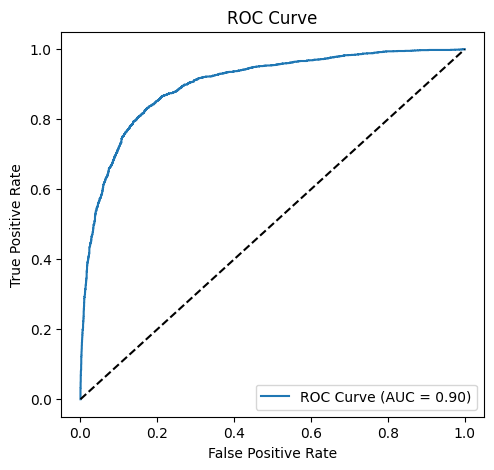

In [38]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_probs)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

Visualisasi Akurasi & Loss

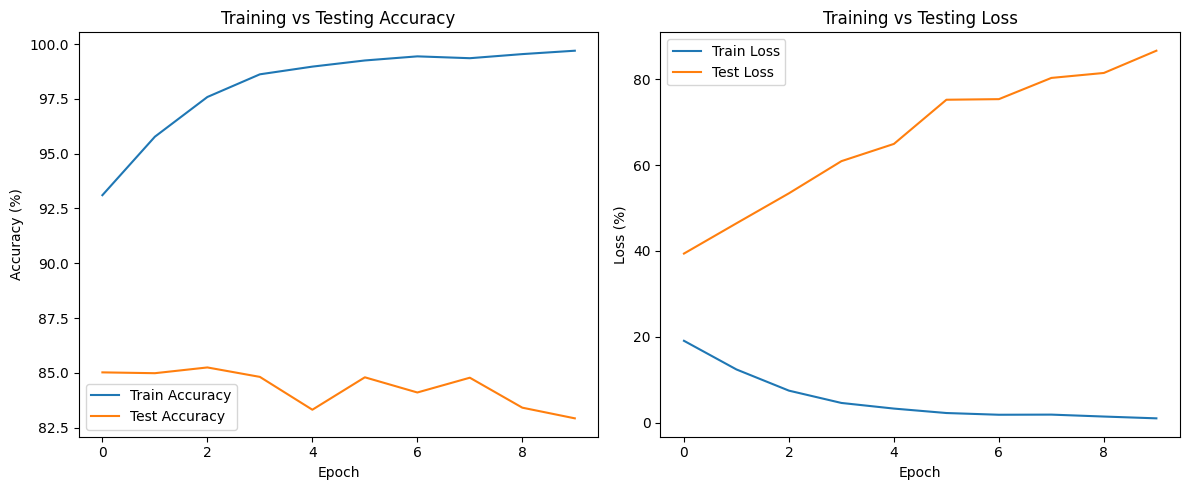

In [40]:
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(np.array(history.history['accuracy']) * 100, label='Train Accuracy')
plt.plot(np.array(history.history['val_accuracy']) * 100, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Testing Accuracy')
plt.legend()

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(np.array(history.history['loss']) * 100, label='Train Loss')
plt.plot(np.array(history.history['val_loss']) * 100, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (%)')
plt.title('Training vs Testing Loss')
plt.legend()

plt.tight_layout()
plt.show()
